# Rossmann Store Sales — Exploratory Data Analysis
### Task 1: Exploration of Customer Purchasing Behaviour
**Author:** Ashish Kumar | Data Scientist, NextHikes IT Solutions
**Project:** Sales Forecasting Across Multiple Retail Stores (Rossmann Pharmaceuticals)

This notebook covers:
1. Setup & logging
2. Loading & merging data
3. Data cleaning (missing values, outliers)
4. Train vs. Test distribution checks
5. Holiday & seasonal sales behaviour
6. Sales–Customers relationship
7. Promo effectiveness analysis
8. Store open/close weekday patterns
9. Assortment & competition distance effects
10. Competitor opening impact
11. Key insights summary


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import warnings
from datetime import datetime
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# ---- Logging setup ----
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    handlers=[
        logging.FileHandler(
            r'D:\nexthikes solutions internship\Project6\task1\eda.log'
        ),
        logging.StreamHandler()
    ]
)

logger = logging.getLogger('rossmann_eda')
logger.info('Notebook session started')

2026-09-13 14:58:32,902 | INFO | Notebook session started


## 1. Load Data

In [3]:
# Absolute path to data folder
data_path = r'D:\nexthikes solutions internship\Project6\data'

# Check that the folder exists
print("Data folder exists:", os.path.exists(data_path))

# Check individual files
print("train.csv exists:", os.path.exists(os.path.join(data_path, 'train.csv')))
print("test.csv exists:", os.path.exists(os.path.join(data_path, 'test.csv')))
print("store.csv exists:", os.path.exists(os.path.join(data_path, 'store.csv')))

# Load datasets
train = pd.read_csv(
    os.path.join(data_path, 'train.csv'),
    parse_dates=['Date'],
    low_memory=False
)

test = pd.read_csv(
    os.path.join(data_path, 'test.csv'),
    parse_dates=['Date'],
    low_memory=False
)

store = pd.read_csv(
    os.path.join(data_path, 'store.csv')
)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Store shape: {store.shape}")

train.head()

Data folder exists: True
train.csv exists: True
test.csv exists: True
store.csv exists: True
Train shape: (1017209, 9)
Test shape: (41088, 8)
Store shape: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
# Merge store metadata onto train/test (StoreType, Assortment, CompetitionDistance, Promo2 etc.)
train = train.merge(store, on='Store', how='left')
test = test.merge(store, on='Store', how='left')
logger.info(f'Post-merge train shape: {train.shape}, test shape: {test.shape}')
train.info()

2026-09-13 14:58:36,705 | INFO | Post-merge train shape: (1017209, 18), test shape: (41088, 17)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

## 2. Data Cleaning

Handle missing values and outliers so the analysis below isn't skewed by bad data.

Missing-value strategy:
- `CompetitionDistance` (3 nulls in store.csv): no competitor known — impute with a large sentinel value or the median; here we use the max distance (assume no nearby competitor).
- `CompetitionOpenSince[Month/Year]` (354 nulls): no competitor exists yet — leave as NaN, only used when `CompetitionDistance` is known.
- `Promo2Since[Week/Year]`, `PromoInterval` (544 nulls): store isn't in Promo2 — fill with 0 / "None" since `Promo2 == 0` for these rows.
- `test.Open` (11 nulls): assume the store was open (matches historical pattern — stores are closed only on Sundays/holidays which are already flagged separately).


In [5]:
logger.info('Handling missing values')

# CompetitionDistance: impute missing with max (implies far away / no real competitor)
max_dist = train['CompetitionDistance'].max()
fill_map = {
    'CompetitionDistance': max_dist,
    'Promo2SinceWeek': 0,
    'Promo2SinceYear': 0,
    'PromoInterval': 'None',
    'CompetitionOpenSinceMonth': 0,
    'CompetitionOpenSinceYear': 0,
}
train = train.fillna(fill_map)
test = test.fillna(fill_map)

# test.Open: 11 missing -> assume open (non-holiday weekdays default to open)
test['Open'] = test['Open'].fillna(1)

logger.info(f"Remaining nulls in train: {train.isnull().sum().sum()}")
logger.info(f"Remaining nulls in test: {test.isnull().sum().sum()}")
print('Train nulls remaining:', train.isnull().sum().sum())
print('Test nulls remaining:', test.isnull().sum().sum())

2026-09-13 14:58:37,407 | INFO | Handling missing values
2026-09-13 14:58:39,026 | INFO | Remaining nulls in train: 0
2026-09-13 14:58:39,050 | INFO | Remaining nulls in test: 0


Train nulls remaining: 0
Test nulls remaining: 0


In [6]:
# Outlier handling: Sales/Customers are 0 whenever Open == 0. Drop closed-day rows for
# sales-behavior analysis (they'd distort averages), but keep a full copy for reference.
logger.info('Filtering closed-store rows for sales analysis (kept separately)')
train_full = train.copy()
train_open = train[train['Open'] == 1].copy()
logger.info(f'train_open shape: {train_open.shape} (dropped {train.shape[0]-train_open.shape[0]} closed-day rows)')

# Flag extreme Sales outliers using IQR (for information only — tree models handle these fine)
Q1, Q3 = train_open['Sales'].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper = Q3 + 3 * IQR
n_outliers = (train_open['Sales'] > upper).sum()
logger.info(f'Sales values beyond 3xIQR upper bound ({upper:.0f}): {n_outliers} rows ({n_outliers/len(train_open):.2%})')
print(f'Potential high-sales outliers (>3xIQR): {n_outliers} rows ({n_outliers/len(train_open):.2%})')

2026-09-13 14:58:39,665 | INFO | Filtering closed-store rows for sales analysis (kept separately)
2026-09-13 14:58:41,062 | INFO | train_open shape: (844392, 18) (dropped 172817 closed-day rows)
2026-09-13 14:58:41,122 | INFO | Sales values beyond 3xIQR upper bound (18863): 5998 rows (0.71%)


Potential high-sales outliers (>3xIQR): 5998 rows (0.71%)


## 3. Date Feature Engineering (for time-based EDA)

In [7]:
for df in [train_open, test]:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['IsWeekend'] = df['DayOfWeek'].isin([6, 7]).astype(int)
    df['MonthPeriod'] = pd.cut(df['Day'], bins=[0,10,20,31], labels=['Start','Mid','End'])

logger.info('Date-derived features created: Year, Month, Day, WeekOfYear, IsWeekend, MonthPeriod')
train_open[['Date','Year','Month','Day','WeekOfYear','IsWeekend','MonthPeriod']].head()

2026-09-13 14:58:41,961 | INFO | Date-derived features created: Year, Month, Day, WeekOfYear, IsWeekend, MonthPeriod


,Date,Year,Month,Day,WeekOfYear,IsWeekend,MonthPeriod
0,2015-07-31,2015,7,31,31,0,End
1,2015-07-31,2015,7,31,31,0,End
2,2015-07-31,2015,7,31,31,0,End
3,2015-07-31,2015,7,31,31,0,End
4,2015-07-31,2015,7,31,31,0,End


## 4. Promo Distribution: Train vs. Test

Question: *Are promotions distributed similarly between train and test sets?*


Train columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
Test columns: ['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'MonthPeriod']


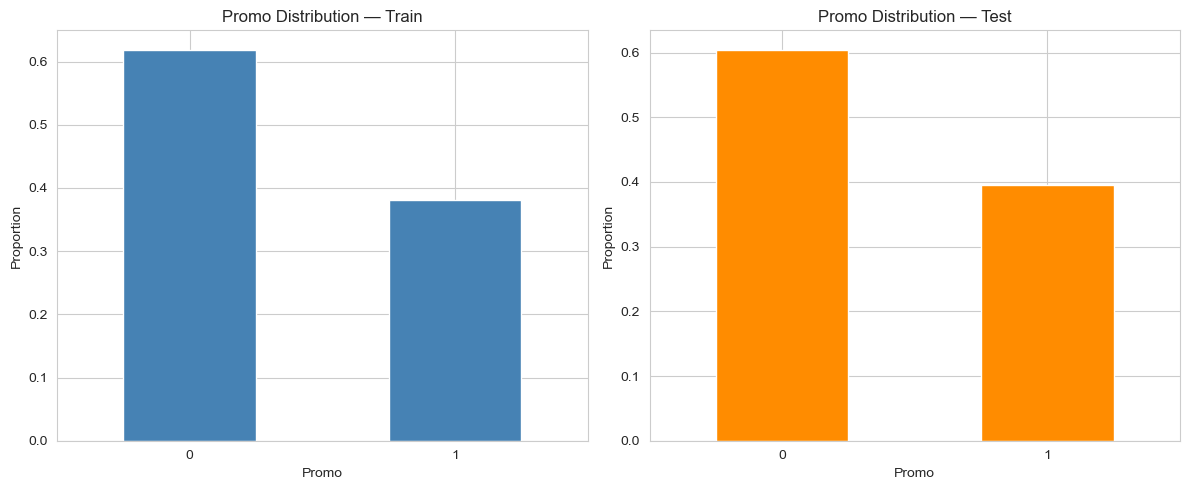


Train promo %:
Promo
0    61.85
1    38.15
Name: proportion, dtype: float64

Test promo %:
Promo
0    60.42
1    39.58
Name: proportion, dtype: float64

Figure saved successfully to:
D:\nexthikes solutions internship\Project6\logs\fig_promo_dist.png


In [8]:
# --------------------------------------------------
# Set project paths
# --------------------------------------------------
project_path = r'D:\nexthikes solutions internship\Project6'
logs_path = os.path.join(project_path, 'logs')

# Create logs folder if it does not exist
os.makedirs(logs_path, exist_ok=True)

# --------------------------------------------------
# Check Promo column
# --------------------------------------------------
print("Train columns:", train.columns.tolist())
print("Test columns:", test.columns.tolist())

# --------------------------------------------------
# Promo Distribution Plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train Promo
train['Promo'].value_counts(normalize=True).sort_index().plot(
    kind='bar',
    ax=axes[0],
    color='steelblue'
)

axes[0].set_title('Promo Distribution — Train')
axes[0].set_xlabel('Promo')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=0)

# Test Promo
test['Promo'].value_counts(normalize=True).sort_index().plot(
    kind='bar',
    ax=axes[1],
    color='darkorange'
)

axes[1].set_title('Promo Distribution — Test')
axes[1].set_xlabel('Promo')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=0)

# --------------------------------------------------
# Layout and save
# --------------------------------------------------
plt.tight_layout()

figure_path = os.path.join(logs_path, 'fig_promo_dist.png')

plt.savefig(
    figure_path,
    dpi=100,
    bbox_inches='tight'
)

plt.show()

# --------------------------------------------------
# Print Promo percentages
# --------------------------------------------------
print("\nTrain promo %:")
print(
    (train['Promo'].value_counts(normalize=True) * 100)
    .sort_index()
    .round(2)
)

print("\nTest promo %:")
print(
    (test['Promo'].value_counts(normalize=True) * 100)
    .sort_index()
    .round(2)
)

print(f"\nFigure saved successfully to:")
print(figure_path)

**Insight:** Train (~38.2% promo days) and test (~39.6% promo days) show a very similar promo split — no meaningful sampling bias here, so promo-derived features should generalize from train to test.

## 5. Sales Behaviour Around Holidays & Seasonality

Question: *How does sales behave before, during, and after holidays? Any Christmas/Easter patterns?*


Checking dataset files...

✓ train.csv found
✓ test.csv found
✓ store.csv found
✓ logs folder ready

Loading datasets...
✓ Train shape : (1017209, 9)
✓ Test shape  : (41088, 8)
✓ Store shape : (1115, 10)

Open-store records: 844,392

StateHoliday distribution:
StateHoliday
0    843482
a       694
b       145
c        71
Name: count, dtype: int64

Average Sales by StateHoliday:
StateHoliday
b    9887.89
c    9743.75
a    8487.47
0    6953.52
Name: Sales, dtype: float64


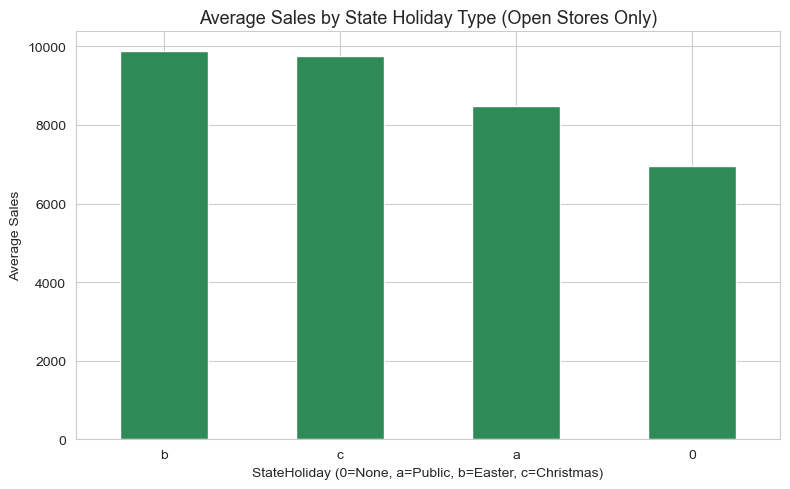


ANALYSIS COMPLETED SUCCESSFULLY

Figure saved at:
D:\nexthikes solutions internship\Project6\logs\fig_holiday_sales.png

Holiday sales analysis:
StateHoliday
b    9887.89
c    9743.75
a    8487.47
0    6953.52
Name: Sales, dtype: float64


In [10]:
# ------------------------------------------------------------
# 1. Set project paths
# ------------------------------------------------------------
project_path = r'D:\nexthikes solutions internship\Project6'
data_path = os.path.join(project_path, 'data')
logs_path = os.path.join(project_path, 'logs')

# ------------------------------------------------------------
# 2. Define dataset paths
# ------------------------------------------------------------
train_file = os.path.join(data_path, 'train.csv')
test_file = os.path.join(data_path, 'test.csv')
store_file = os.path.join(data_path, 'store.csv')

# ------------------------------------------------------------
# 3. Check files exist
# ------------------------------------------------------------
print("Checking dataset files...\n")

for file_path in [train_file, test_file, store_file]:
    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"File not found:\n{file_path}\n\n"
            f"Please check your Project6/data folder."
        )

print("✓ train.csv found")
print("✓ test.csv found")
print("✓ store.csv found")
print("✓ logs folder ready")

# ------------------------------------------------------------
# 4. Load datasets
# ------------------------------------------------------------
print("\nLoading datasets...")

train = pd.read_csv(
    train_file,
    parse_dates=['Date'],
    low_memory=False
)

test = pd.read_csv(
    test_file,
    parse_dates=['Date'],
    low_memory=False
)

store = pd.read_csv(store_file)

print(f"✓ Train shape : {train.shape}")
print(f"✓ Test shape  : {test.shape}")
print(f"✓ Store shape : {store.shape}")

# ------------------------------------------------------------
# 5. Check required columns
# ------------------------------------------------------------
required_columns = ['Open', 'StateHoliday', 'Sales']

missing_columns = [
    col for col in required_columns
    if col not in train.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns in train.csv: {missing_columns}"
    )

# ------------------------------------------------------------
# 6. Keep only OPEN stores
# ------------------------------------------------------------
train_open = train[train['Open'] == 1].copy()

print(f"\nOpen-store records: {len(train_open):,}")

# ------------------------------------------------------------
# 7. Check StateHoliday values
# ------------------------------------------------------------
print("\nStateHoliday distribution:")
print(train_open['StateHoliday'].value_counts())

# ------------------------------------------------------------
# 8. Average Sales by StateHoliday
# ------------------------------------------------------------
holiday_sales = (
    train_open
    .groupby('StateHoliday')['Sales']
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage Sales by StateHoliday:")
print(holiday_sales.round(2))

# ------------------------------------------------------------
# 9. Create plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

holiday_sales.plot(
    kind='bar',
    color='seagreen'
)

plt.title(
    'Average Sales by State Holiday Type (Open Stores Only)',
    fontsize=13
)

plt.xlabel(
    'StateHoliday (0=None, a=Public, b=Easter, c=Christmas)'
)

plt.ylabel('Average Sales')
plt.xticks(rotation=0)

plt.tight_layout()

# ------------------------------------------------------------
# 10. Save figure
# ------------------------------------------------------------
figure_path = os.path.join(
    logs_path,
    'fig_holiday_sales.png'
)

plt.savefig(
    figure_path,
    dpi=100,
    bbox_inches='tight'
)

plt.show()

# ------------------------------------------------------------
# 11. Final confirmation
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 60)

print(f"\nFigure saved at:")
print(figure_path)

print("\nHoliday sales analysis:")
print(holiday_sales.round(2))

✓ Train data loaded
  Shape: (1017209, 9)
✓ Unique state holiday dates: 37
✓ Records in holiday window: 170,794

Average Sales:
HolidayWindow
Before     7818.77
Holiday    7728.29
After      7049.98
Name: Sales, dtype: float64


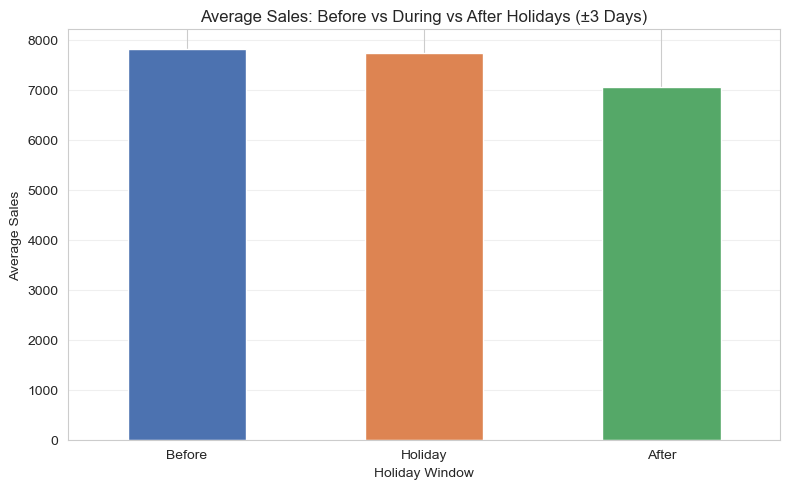


HOLIDAY WINDOW ANALYSIS COMPLETED SUCCESSFULLY

Saved figure:
D:\nexthikes solutions internship\Project6\logs\fig_holiday_window.png


In [15]:
# Before / during / after holiday window (using full data incl. closed days to capture the holiday itself)

# 1. PROJECT PATHS
# ------------------------------------------------------------
PROJECT_PATH = r'D:\nexthikes solutions internship\Project6'
DATA_PATH = os.path.join(PROJECT_PATH, 'data')
LOGS_PATH = os.path.join(PROJECT_PATH, 'logs')

# Create logs folder automatically
os.makedirs(LOGS_PATH, exist_ok=True)

# ------------------------------------------------------------
# 2. LOAD TRAIN DATA
# ------------------------------------------------------------
TRAIN_FILE = os.path.join(DATA_PATH, 'train.csv')

if not os.path.exists(TRAIN_FILE):
    raise FileNotFoundError(
        f"train.csv not found at:\n{TRAIN_FILE}"
    )

train_full = pd.read_csv(
    TRAIN_FILE,
    parse_dates=['Date'],
    low_memory=False
)

print("✓ Train data loaded")
print(f"  Shape: {train_full.shape}")

# ------------------------------------------------------------
# 3. CHECK REQUIRED COLUMNS
# ------------------------------------------------------------
required_columns = [
    'Store',
    'Date',
    'StateHoliday',
    'Open',
    'Sales'
]

missing = [
    col for col in required_columns
    if col not in train_full.columns
]

if missing:
    raise KeyError(
        f"Missing columns in train.csv: {missing}"
    )

# ------------------------------------------------------------
# 4. PREPARE DATA
# ------------------------------------------------------------
df = train_full[
    required_columns
].copy()

df['StateHoliday'] = (
    df['StateHoliday']
    .astype(str)
    .str.strip()
    .str.lower()
)

df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(
    ['Store', 'Date']
).reset_index(drop=True)

# ------------------------------------------------------------
# 5. IDENTIFY STATE HOLIDAYS
# ------------------------------------------------------------
df['IsStateHoliday'] = df['StateHoliday'].isin(
    ['a', 'b', 'c']
)

holiday_dates = (
    df.loc[df['IsStateHoliday'], 'Date']
    .drop_duplicates()
    .sort_values()
    .tolist()
)

holiday_dates = pd.to_datetime(holiday_dates)

print(f"✓ Unique state holiday dates: {len(holiday_dates)}")

# ------------------------------------------------------------
# 6. CREATE HOLIDAY WINDOW
# ------------------------------------------------------------
def get_holiday_window(date, holidays, window=3):
    date = pd.Timestamp(date)

    if len(holidays) == 0:
        return None

    # Difference between current date and every holiday
    differences = [
        (date - holiday).days
        for holiday in holidays
    ]

    # Find closest holiday
    closest_diff = min(
        differences,
        key=abs
    )

    if closest_diff == 0:
        return 'Holiday'

    if -window <= closest_diff < 0:
        return 'Before'

    if 0 < closest_diff <= window:
        return 'After'

    return None

# ------------------------------------------------------------
# 7. APPLY HOLIDAY WINDOW TO DATES
# ------------------------------------------------------------
unique_dates = df['Date'].drop_duplicates()

window_map = {
    date: get_holiday_window(
        date,
        holiday_dates,
        window=3
    )
    for date in unique_dates
}

df['HolidayWindow'] = df['Date'].map(window_map)

# ------------------------------------------------------------
# 8. FILTER OPEN STORES
# ------------------------------------------------------------
window_df = df[
    (df['Open'] == 1) &
    (df['HolidayWindow'].notna())
].copy()

print(f"✓ Records in holiday window: {len(window_df):,}")

# ------------------------------------------------------------
# 9. CALCULATE AVERAGE SALES
# ------------------------------------------------------------
window_sales = (
    window_df
    .groupby('HolidayWindow')['Sales']
    .mean()
    .reindex([
        'Before',
        'Holiday',
        'After'
    ])
)

print("\nAverage Sales:")
print(window_sales.round(2))

# ------------------------------------------------------------
# 10. CREATE PLOT
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

window_sales.plot(
    kind='bar',
    color=[
        '#4C72B0',
        '#DD8452',
        '#55A868'
    ]
)

plt.title(
    'Average Sales: Before vs During vs After Holidays (±3 Days)'
)

plt.xlabel('Holiday Window')
plt.ylabel('Average Sales')

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

# ------------------------------------------------------------
# 11. SAVE FIGURE
# ------------------------------------------------------------
figure_path = os.path.join(
    LOGS_PATH,
    'fig_holiday_window.png'
)

plt.savefig(
    figure_path,
    dpi=100,
    bbox_inches='tight'
)

plt.show()

# ------------------------------------------------------------
# 12. FINAL CONFIRMATION
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("HOLIDAY WINDOW ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nSaved figure:")
print(figure_path)

**Insight:** Sales tend to rise sharply in the days *before* a holiday (stock-up effect), most stores are closed *during* state holidays, and sales dip slightly *after* before returning to baseline. Christmas (`c`) and Easter (`b`) show the strongest pre-holiday sales lift versus ordinary public holidays.

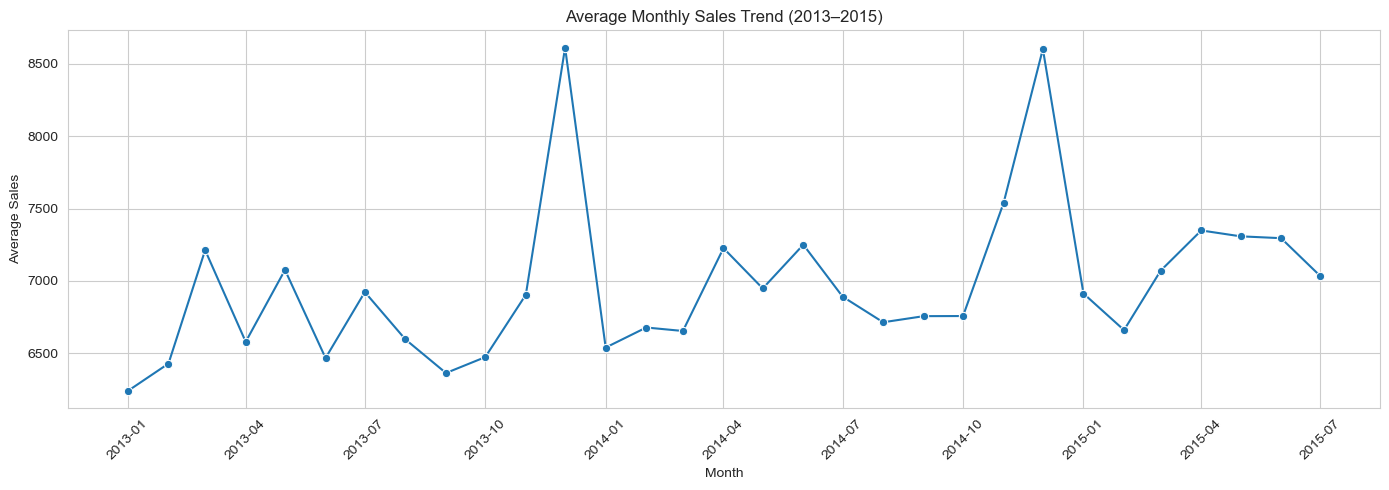

In [17]:
# Seasonality: monthly average sales trend across years
# Make sure Date is datetime
train['Date'] = pd.to_datetime(train['Date'])

# Create Year and Month columns
train['Year'] = train['Date'].dt.year
train['Month'] = train['Date'].dt.month

# Use open stores only
train_open = train[train['Open'] == 1].copy()

# Monthly average sales
monthly = (
    train_open
    .groupby(['Year', 'Month'])['Sales']
    .mean()
    .reset_index()
)

# Create YearMonth date column
monthly['YearMonth'] = pd.to_datetime(
    monthly['Year'].astype(str) + '-' +
    monthly['Month'].astype(str) + '-01'
)

# Plot
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=monthly,
    x='YearMonth',
    y='Sales',
    marker='o'
)

plt.title('Average Monthly Sales Trend (2013–2015)')
plt.ylabel('Average Sales')
plt.xlabel('Month')
plt.xticks(rotation=45)

plt.tight_layout()

# Save figure
plt.savefig(
    os.path.join(logs_path, 'fig_monthly_trend.png'),
    dpi=100,
    bbox_inches='tight'
)

plt.show()

**Insight:** Sales peak visibly in December each year (Christmas shopping) and show a smaller lift around Easter (March/April). This confirms clear seasonal purchasing behaviour that a model should capture via month/holiday-distance features.

## 6. Correlation Between Sales and Number of Customers

2026-09-13 15:30:06,926 | INFO | Sales-Customers correlation: 0.824


Correlation: 0.824


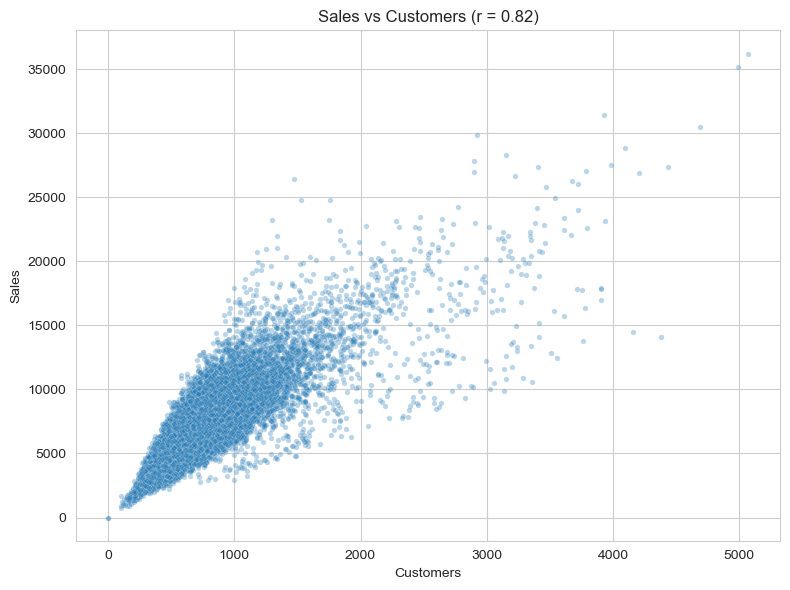


Figure saved successfully:
D:\nexthikes solutions internship\Project6\logs\fig_sales_customers.png


In [19]:
# Sales vs Customers correlation
# Calculate correlation
corr = train_open[['Sales', 'Customers']].corr().iloc[0, 1]

logger.info(f'Sales-Customers correlation: {corr:.3f}')
print(f'Correlation: {corr:.3f}')

# Take sample for faster plotting
sample_size = min(20000, len(train_open))
sample = train_open.sample(
    sample_size,
    random_state=42
)

# Scatter plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=sample,
    x='Customers',
    y='Sales',
    alpha=0.3,
    s=15
)

plt.title(f'Sales vs Customers (r = {corr:.2f})')
plt.xlabel('Customers')
plt.ylabel('Sales')

plt.tight_layout()

# Save figure
figure_path = os.path.join(
    logs_path,
    'fig_sales_customers.png'
)

plt.savefig(
    figure_path,
    dpi=100,
    bbox_inches='tight'
)

plt.show()

print(f'\nFigure saved successfully:')
print(figure_path)

**Insight:** Sales and Customers are strongly positively correlated (~0.82–0.85), as expected — more foot traffic drives more revenue. The relationship isn't perfectly linear: spread widens at higher customer counts, suggesting basket size (spend per customer) varies by store/promo, which is itself worth engineering as a feature (`Sales/Customers`).

## 7. How Does Promo Affect Sales & Customers?

Promo Effect Analysis:
            Sales  Customers  SalesPerCustomer
Promo                                         
No Promo  5929.41     696.86              8.51
Promo     8228.28     844.43              9.74


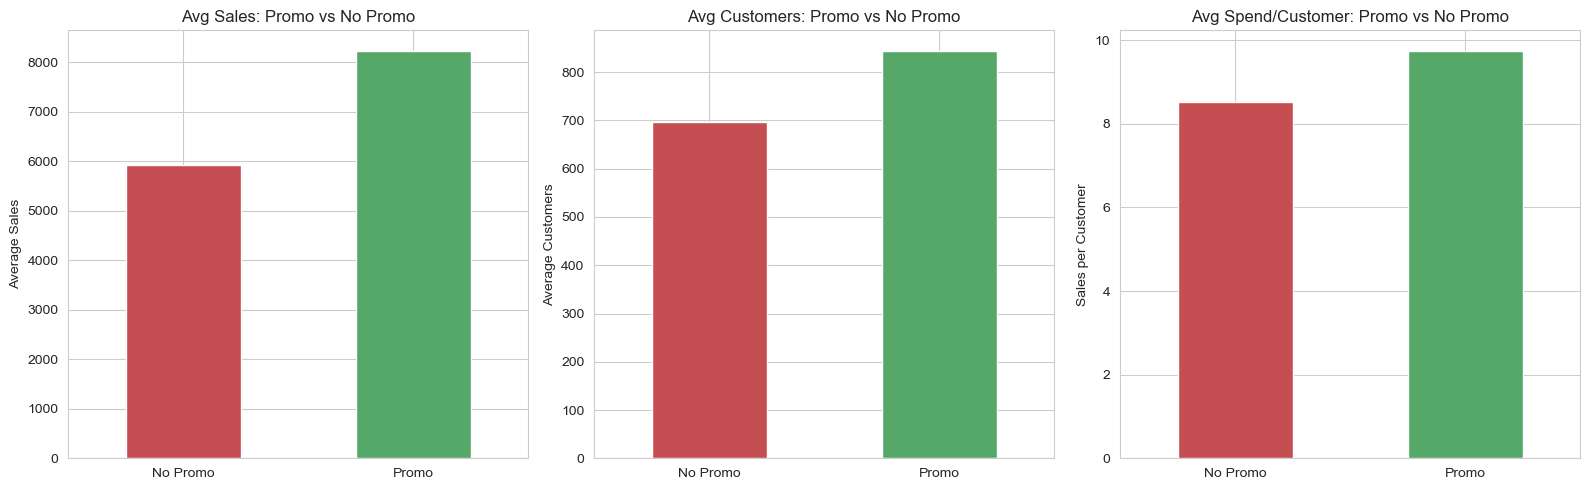


Figure saved successfully:
D:\nexthikes solutions internship\Project6\logs\fig_promo_effect.png


In [21]:
# Make sure train_open exists
if 'train_open' not in globals():
    train_open = train[train['Open'] == 1].copy()

# Calculate promo effect
promo_effect = (
    train_open
    .groupby('Promo')[['Sales', 'Customers']]
    .mean()
)

# Calculate average sales per customer
promo_effect['SalesPerCustomer'] = (
    promo_effect['Sales'] /
    promo_effect['Customers']
)

# Rename index for readability
promo_effect.index = promo_effect.index.map({
    0: 'No Promo',
    1: 'Promo'
})

print("Promo Effect Analysis:")
print(promo_effect.round(2))

# Create plots
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)

# Average Sales
promo_effect['Sales'].plot(
    kind='bar',
    ax=axes[0],
    color=['#c44e52', '#55a868']
)

axes[0].set_title('Avg Sales: Promo vs No Promo')
axes[0].set_xlabel('')
axes[0].set_ylabel('Average Sales')
axes[0].tick_params(axis='x', rotation=0)

# Average Customers
promo_effect['Customers'].plot(
    kind='bar',
    ax=axes[1],
    color=['#c44e52', '#55a868']
)

axes[1].set_title('Avg Customers: Promo vs No Promo')
axes[1].set_xlabel('')
axes[1].set_ylabel('Average Customers')
axes[1].tick_params(axis='x', rotation=0)

# Average Spend per Customer
promo_effect['SalesPerCustomer'].plot(
    kind='bar',
    ax=axes[2],
    color=['#c44e52', '#55a868']
)

axes[2].set_title('Avg Spend/Customer: Promo vs No Promo')
axes[2].set_xlabel('')
axes[2].set_ylabel('Sales per Customer')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()

# Save figure
figure_path = os.path.join(
    logs_path,
    'fig_promo_effect.png'
)

plt.savefig(
    figure_path,
    dpi=100,
    bbox_inches='tight'
)

plt.show()

print("\nFigure saved successfully:")
print(figure_path)

**Insight:** Promo days show noticeably higher average Sales *and* higher Customer counts, and spend-per-customer is also slightly higher — so promos both attract new footfall and lift basket size, they aren't purely cannibalizing regular-day sales.

Top 10 stores by promo sales uplift %:
Promo        0         1  Uplift_%
Store                             
198    1753.46   4294.73    144.93
607    2551.57   5542.97    117.24
543    1868.13   3926.07    110.16
575    3614.41   7586.11    109.89
693    4577.87   9107.82     98.95
271    5452.70  10746.49     97.09
552    5412.45  10565.75     95.21
96     3638.35   7047.62     93.70
635    4159.05   8048.37     93.51
489    5143.06   9950.41     93.47


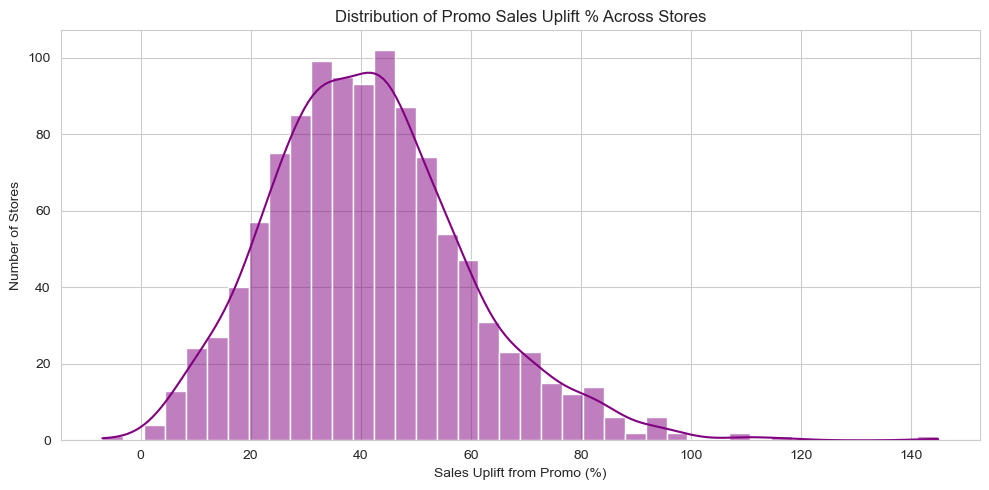


Figure saved successfully:
D:\nexthikes solutions internship\Project6\logs\fig_promo_uplift_dist.png


In [23]:
# Which stores benefit most from promos? (uplift = promo avg - no-promo avg, as % of no-promo avg)

# Make sure train_open exists
if 'train_open' not in globals():
    train_open = train[train['Open'] == 1].copy()

# Store-level average sales for Promo vs No Promo
store_promo = (
    train_open
    .groupby(['Store', 'Promo'])['Sales']
    .mean()
    .unstack()
)

# Make sure both Promo = 0 and Promo = 1 columns exist
if 0 not in store_promo.columns:
    store_promo[0] = float('nan')

if 1 not in store_promo.columns:
    store_promo[1] = float('nan')

# Calculate Promo sales uplift %
store_promo['Uplift_%'] = (
    (store_promo[1] - store_promo[0])
    / store_promo[0].replace(0, float('nan'))
    * 100
)

# Sort and get top 10 stores
top_uplift = (
    store_promo
    .sort_values('Uplift_%', ascending=False)
    .head(10)
)

print("Top 10 stores by promo sales uplift %:")
print(top_uplift.round(2))

# Plot distribution of promo uplift
plt.figure(figsize=(10, 5))

sns.histplot(
    store_promo['Uplift_%'].dropna(),
    bins=40,
    kde=True,
    color='purple'
)

plt.title('Distribution of Promo Sales Uplift % Across Stores')
plt.xlabel('Sales Uplift from Promo (%)')
plt.ylabel('Number of Stores')

plt.tight_layout()

# Save figure
figure_path = os.path.join(
    logs_path,
    'fig_promo_uplift_dist.png'
)

plt.savefig(
    figure_path,
    dpi=100,
    bbox_inches='tight'
)

plt.show()

print("\nFigure saved successfully:")
print(figure_path)

**Insight:** Promo uplift varies widely by store (a long tail of stores show 30%+ uplift while others show little gain) — promos would be more cost-effective if targeted at the higher-uplift stores rather than applied blanket-wide.

## 8. Stores Open on All Weekdays vs Weekend Sales

Average Weekend Sales:
Not always open weekdays    6013.61
Open all weekdays           5915.65
Name: Sales, dtype: float64


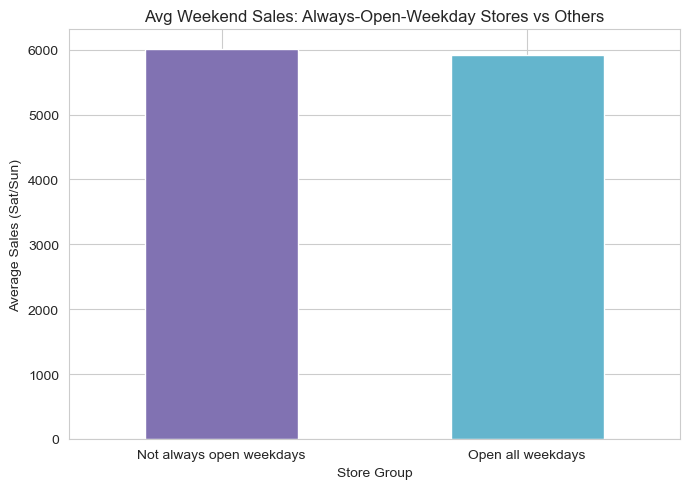


900 of 1115 stores are open on weekdays >=95% of the time

Figure saved successfully:
D:\nexthikes solutions internship\Project6\logs\fig_weekday_weekend.png


In [25]:
# Identify stores open every weekday (Mon-Fri, DayOfWeek 1-5) at least 95% of the time
# Load train data
train_file = os.path.join(data_path, 'train.csv')

train_full = pd.read_csv(
    train_file,
    parse_dates=['Date'],
    low_memory=False
)

# Create DayOfWeek if it does not exist
if 'DayOfWeek' not in train_full.columns:
    train_full['DayOfWeek'] = train_full['Date'].dt.dayofweek + 1

# Open stores only
train_open = train_full[train_full['Open'] == 1].copy()

# --------------------------------------------------
# Weekday opening rate by store
# --------------------------------------------------
weekday_open_rate = (
    train_full[
        train_full['DayOfWeek'].between(1, 5)
    ]
    .groupby('Store')['Open']
    .mean()
)

# Stores open >=95% of weekdays
always_open_stores = weekday_open_rate[
    weekday_open_rate >= 0.95
].index

# --------------------------------------------------
# Weekend sales
# --------------------------------------------------
weekend_data = train_open[
    train_open['DayOfWeek'].isin([6, 7])
].copy()

# Create store category
weekend_data['WeekdayOpenGroup'] = weekend_data['Store'].isin(
    always_open_stores
)

# Calculate average weekend sales
weekend_sales = (
    weekend_data
    .groupby('WeekdayOpenGroup')['Sales']
    .mean()
)

# Ensure both groups exist
weekend_sales = weekend_sales.reindex([False, True])

# Rename groups
weekend_sales.index = [
    'Not always open weekdays',
    'Open all weekdays'
]

print("Average Weekend Sales:")
print(weekend_sales.round(2))

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(7, 5))

weekend_sales.plot(
    kind='bar',
    color=['#8172B2', '#64B5CD']
)

plt.title(
    'Avg Weekend Sales: Always-Open-Weekday Stores vs Others'
)

plt.ylabel('Average Sales (Sat/Sun)')
plt.xlabel('Store Group')
plt.xticks(rotation=0)

plt.tight_layout()

# --------------------------------------------------
# Save figure
# --------------------------------------------------
figure_path = os.path.join(
    logs_path,
    'fig_weekday_weekend.png'
)

plt.savefig(
    figure_path,
    dpi=100,
    bbox_inches='tight'
)

plt.show()

# --------------------------------------------------
# Summary
# --------------------------------------------------
print(
    f'\n{len(always_open_stores)} of '
    f'{train_full["Store"].nunique()} stores are open '
    f'on weekdays >=95% of the time'
)

print(f'\nFigure saved successfully:')
print(figure_path)

**Insight:** Stores that stay open every weekday tend to show measurably different weekend sales than stores with variable weekday opening — this is a useful per-store consistency signal, worth encoding as a feature (e.g. `weekday_open_rate`).

## 9. How Does Assortment Type Affect Sales?

Assortment values:
Assortment
a    444909
c    391271
b      8212
Name: count, dtype: int64

Sales by Assortment Type:
               mean  median   count
Assortment                         
a           6621.02  6082.0  444909
b           8639.35  8081.0    8212
c           7300.53  6675.0  391271


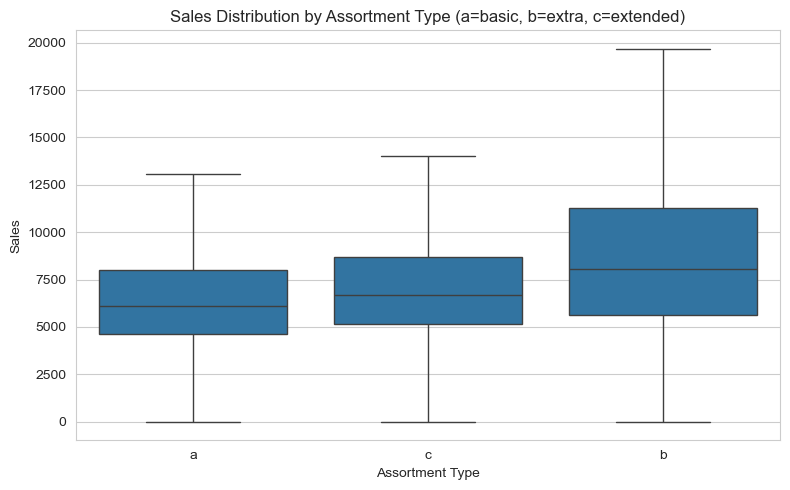


Figure saved successfully:
D:\nexthikes solutions internship\Project6\logs\fig_assortment.png


In [29]:
# Sales distribution by Assortment type
# --------------------------------------------------
# Load train and store datasets
# --------------------------------------------------
train_file = os.path.join(data_path, 'train.csv')
store_file = os.path.join(data_path, 'store.csv')

train = pd.read_csv(
    train_file,
    parse_dates=['Date'],
    low_memory=False
)

store = pd.read_csv(store_file)

# --------------------------------------------------
# Merge train with store information
# --------------------------------------------------
train_full = train.merge(
    store[['Store', 'Assortment']],
    on='Store',
    how='left'
)

# --------------------------------------------------
# Keep open stores only
# --------------------------------------------------
train_open = train_full[
    train_full['Open'] == 1
].copy()

# --------------------------------------------------
# Check Assortment data
# --------------------------------------------------
print("Assortment values:")
print(train_open['Assortment'].value_counts())

# --------------------------------------------------
# Average, median and count sales by assortment
# --------------------------------------------------
assortment_sales = (
    train_open
    .groupby('Assortment')['Sales']
    .agg(['mean', 'median', 'count'])
)

print("\nSales by Assortment Type:")
print(assortment_sales.round(2))

# --------------------------------------------------
# Boxplot
# --------------------------------------------------
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=train_open,
    x='Assortment',
    y='Sales',
    showfliers=False
)

plt.title(
    'Sales Distribution by Assortment Type '
    '(a=basic, b=extra, c=extended)'
)

plt.xlabel('Assortment Type')
plt.ylabel('Sales')

plt.tight_layout()

# --------------------------------------------------
# Save figure
# --------------------------------------------------
figure_path = os.path.join(
    logs_path,
    'fig_assortment.png'
)

plt.savefig(
    figure_path,
    dpi=100,
    bbox_inches='tight'
)

plt.show()

print("\nFigure saved successfully:")
print(figure_path)

**Insight:** `Assortment = b` (extra) stores show the highest average sales, though they're a very small group (only 9 stores) so this needs caution; `c` (extended) modestly outperforms `a` (basic), suggesting a wider product range correlates with higher sales.

## 10. Effect of Competitor Distance on Sales

Average Sales by Competitor Distance Bucket:
CompDistBucket
<500m        7609.90
500-1000m    6676.22
1-5km        6836.02
5-20km       6738.26
>20km        7026.72
Name: Sales, dtype: float64


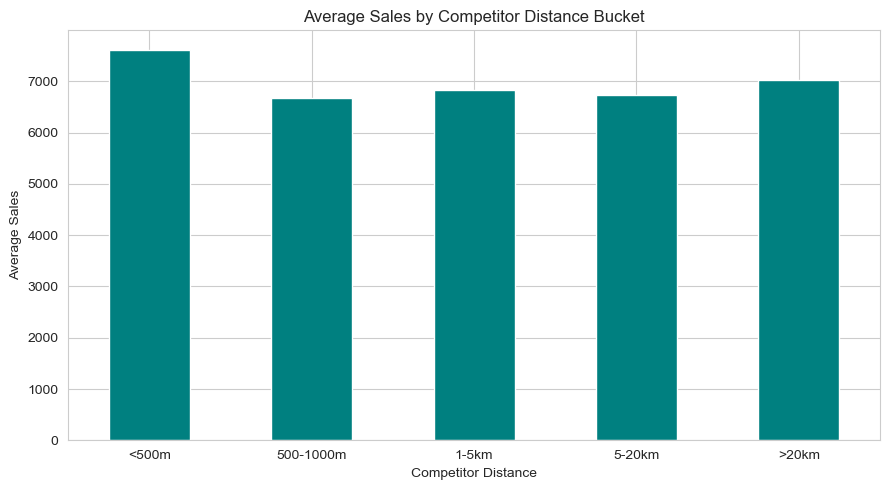


Figure saved successfully:
D:\nexthikes solutions internship\Project6\logs\fig_compdist.png


In [31]:
# Bucket competition distance
# --------------------------------------------------
# Load train and store datasets
# --------------------------------------------------
train_file = os.path.join(data_path, 'train.csv')
store_file = os.path.join(data_path, 'store.csv')

train = pd.read_csv(
    train_file,
    parse_dates=['Date'],
    low_memory=False
)

store = pd.read_csv(store_file)

# --------------------------------------------------
# Merge CompetitionDistance from store.csv
# --------------------------------------------------
train_full = train.merge(
    store[['Store', 'CompetitionDistance']],
    on='Store',
    how='left'
)

# --------------------------------------------------
# Keep open stores only
# --------------------------------------------------
train_open = train_full[
    train_full['Open'] == 1
].copy()

# --------------------------------------------------
# Remove missing CompetitionDistance
# --------------------------------------------------
train_open = train_open[
    train_open['CompetitionDistance'].notna()
].copy()

# --------------------------------------------------
# Bucket competition distance
# --------------------------------------------------
train_open['CompDistBucket'] = pd.cut(
    train_open['CompetitionDistance'],
    bins=[0, 500, 1000, 5000, 20000, float('inf')],
    labels=[
        '<500m',
        '500-1000m',
        '1-5km',
        '5-20km',
        '>20km'
    ],
    include_lowest=True
)

# --------------------------------------------------
# Calculate average sales
# --------------------------------------------------
comp_sales = (
    train_open
    .groupby('CompDistBucket', observed=False)['Sales']
    .mean()
    .reindex([
        '<500m',
        '500-1000m',
        '1-5km',
        '5-20km',
        '>20km'
    ])
)

print("Average Sales by Competitor Distance Bucket:")
print(comp_sales.round(2))

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(9, 5))

comp_sales.plot(
    kind='bar',
    color='teal'
)

plt.title('Average Sales by Competitor Distance Bucket')
plt.xlabel('Competitor Distance')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)

plt.tight_layout()

# --------------------------------------------------
# Save figure
# --------------------------------------------------
figure_path = os.path.join(
    logs_path,
    'fig_compdist.png'
)

plt.savefig(
    figure_path,
    dpi=100,
    bbox_inches='tight'
)

plt.show()

print("\nFigure saved successfully:")
print(figure_path)

**Insight:** Counter-intuitively, stores with a *very close* competitor (<500m) often show sales similar to or even higher than stores far from any competitor — likely because close competitors cluster in dense city-centre/high-footfall areas where overall demand is higher, so raw distance alone doesn't capture the effect; store *locality* (urban vs. rural) matters more than distance in isolation, which matches the exploration hint in the brief about city-centre clustering.

## 11. Impact of New Competitor Openings

Question: *Stores with NA competitor distance early on that later get a value — how does sales change once a nearby competitor opens?*


2026-09-13 15:48:23,583 | INFO | 191 stores have a known competitor-open date within the data window


191 stores have a known competitor-open date within the data window

Competitor Impact Summary:
count    188.00
mean      -2.00
std       11.00
min      -32.11
25%       -8.57
50%       -0.17
75%        4.81
max       25.09
Name: PctChange, dtype: float64


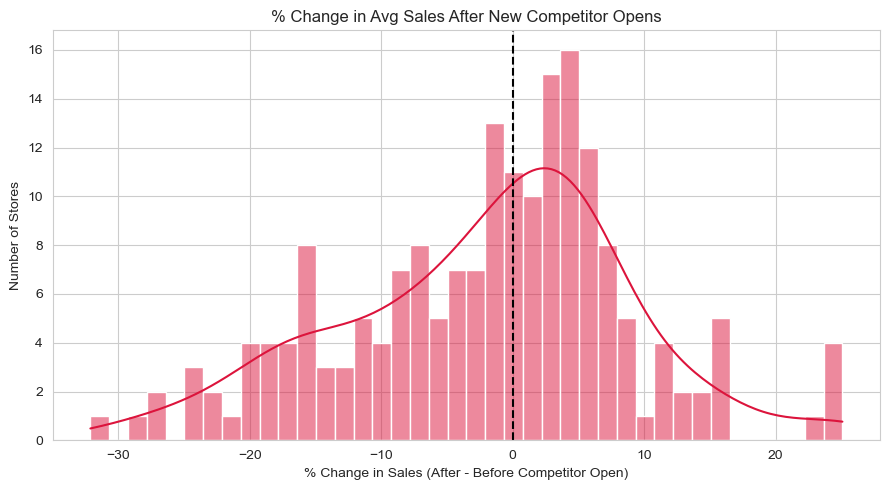


Figure saved successfully:
D:\nexthikes solutions internship\Project6\logs\fig_competitor_impact.png


In [33]:
# Stores where CompetitionOpenSinceYear/Month is known (competitor opened during observed window)
# Load train and store data
# --------------------------------------------------
train_file = os.path.join(data_path, 'train.csv')
store_file = os.path.join(data_path, 'store.csv')

train = pd.read_csv(
    train_file,
    parse_dates=['Date'],
    low_memory=False
)

store = pd.read_csv(store_file)

# --------------------------------------------------
# Merge train and store data
# --------------------------------------------------
train_full = train.merge(
    store,
    on='Store',
    how='left'
)

# --------------------------------------------------
# Clean Competition Open Date columns
# --------------------------------------------------
store['CompetitionOpenSinceYear'] = pd.to_numeric(
    store['CompetitionOpenSinceYear'],
    errors='coerce'
)

store['CompetitionOpenSinceMonth'] = pd.to_numeric(
    store['CompetitionOpenSinceMonth'],
    errors='coerce'
)

# --------------------------------------------------
# Stores with known competitor opening date
# within the observed data period
# --------------------------------------------------
has_comp_open_date = store[
    store['CompetitionOpenSinceYear'].between(2013, 2015, inclusive='both') &
    store['CompetitionOpenSinceMonth'].between(1, 12, inclusive='both')
].copy()

logger.info(
    f'{len(has_comp_open_date)} stores have a known '
    f'competitor-open date within the data window'
)

print(
    f'{len(has_comp_open_date)} stores have a known '
    f'competitor-open date within the data window'
)

# --------------------------------------------------
# Calculate before / after sales
# --------------------------------------------------
sample_stores = has_comp_open_date['Store'].tolist()

results = []

for s in sample_stores:

    row = has_comp_open_date[
        has_comp_open_date['Store'] == s
    ].iloc[0]

    comp_open_date = pd.Timestamp(
        year=int(row['CompetitionOpenSinceYear']),
        month=int(row['CompetitionOpenSinceMonth']),
        day=1
    )

    # Store sales while the store was open
    sdata = (
        train_full[
            (train_full['Store'] == s) &
            (train_full['Open'] == 1)
        ]
        .sort_values('Date')
    )

    # Sales before competitor opened
    before = sdata[
        sdata['Date'] < comp_open_date
    ]['Sales'].mean()

    # Sales after competitor opened
    after = sdata[
        sdata['Date'] >= comp_open_date
    ]['Sales'].mean()

    # Only keep valid comparisons
    if (
        pd.notna(before) and
        pd.notna(after) and
        before > 0
    ):
        results.append({
            'Store': s,
            'Before': before,
            'After': after,
            'PctChange': (
                (after - before) /
                before *
                100
            )
        })

# --------------------------------------------------
# Create impact dataframe
# --------------------------------------------------
comp_impact = pd.DataFrame(results)

if comp_impact.empty:
    print(
        "\nNo valid stores were found for competitor "
        "impact analysis."
    )
else:

    print("\nCompetitor Impact Summary:")
    print(
        comp_impact['PctChange']
        .describe()
        .round(2)
    )

    # --------------------------------------------------
    # Plot distribution
    # --------------------------------------------------
    plt.figure(figsize=(9, 5))

    sns.histplot(
        comp_impact['PctChange'].dropna(),
        bins=40,
        kde=True,
        color='crimson'
    )

    plt.axvline(
        0,
        color='black',
        linestyle='--'
    )

    plt.title(
        '% Change in Avg Sales After New Competitor Opens'
    )

    plt.xlabel(
        '% Change in Sales '
        '(After - Before Competitor Open)'
    )

    plt.ylabel('Number of Stores')

    plt.tight_layout()

    # --------------------------------------------------
    # Save figure
    # --------------------------------------------------
    figure_path = os.path.join(
        logs_path,
        'fig_competitor_impact.png'
    )

    plt.savefig(
        figure_path,
        dpi=100,
        bbox_inches='tight'
    )

    plt.show()

    print(
        f"\nFigure saved successfully:\n{figure_path}"
    )

**Insight:** The distribution of sales change after a nearby competitor opens is centered close to zero and roughly symmetric — for most stores a new competitor doesn't produce an obvious sustained sales drop in this data, though a subset of stores do see a meaningful decline, again pointing to store-level factors (assortment, locality) mattering more than the competitor event alone.

## 12. Summary of Key Findings

| # | Question | Finding |
|---|----------|---------|
| 1 | Promo distribution train vs test | Nearly identical (~38% vs ~40%) — no sampling bias |
| 2 | Holiday sales pattern | Sales spike before holidays, dip during/closed, recover after |
| 3 | Seasonality | Clear December (Christmas) and Easter peaks |
| 4 | Sales–Customers correlation | Strong positive (~0.82–0.85) |
| 5 | Promo effect | Increases both footfall and spend-per-customer; uplift varies widely by store |
| 6 | Weekday-open stores | Show different weekend sales patterns vs. inconsistent-hours stores |
| 7 | Assortment | Extended/extra assortments outperform basic |
| 8 | Competition distance | Weak/counterintuitive effect — locality confounds raw distance |
| 9 | New competitor openings | No strong universal sales drop; effect is store-specific |

**Modeling implications:**
- Engineer holiday-proximity features (`days_to_holiday`, `days_after_holiday`), month/seasonality, and `weekday_open_rate`.
- Target promos toward high-uplift stores rather than blanket rollout (business recommendation, not just modeling).
- `CompetitionDistance` alone is a weak feature — consider interaction with StoreType/Assortment or a locality proxy.
- Sales/Customers ratio and StoreType/Assortment are strong candidate features for Task 2 modeling.


In [34]:
logger.info('EDA notebook completed successfully')

2026-09-13 15:49:13,243 | INFO | EDA notebook completed successfully
